# Study 8: 4-D inference — (length_scale, mu_0, sigma, beta_speaker) via Laplace + VBMC

Study 8 uses **feature set 1** (2d embedding). Each participant heard `total_utt` statements
about a random subset of the 16 train features, `num_generics` of them generic (u=0) and the
rest specific (u=1), per their `training_structure`/`training_features_order`; 15 design
conditions (baseline + num_generics/total_utt combos). Participants are grouped by their exact
feature→utterance configuration (~400 unique groups; the all-G / all-S / baseline conditions
collapse), and the likelihood is the sum of per-group Laplace `log Z` terms — each group gets
its own GP coherence field anchored at its own trained features.

Exclusions mirror `analyses/study 8/study8_analysis.Rmd` (attention check, AI, task check).
Model spec mirrors the study 9 canonical run: 4-D VBMC over
`phi4 = [log_ls, mu_0, log_sigma, log_beta]` with per-feature linking shapes PROFILED OUT
(`inference.run_vbmc_free_shapes_beta`). Results cached — delete files under
`results/study8-vbmc-laplace-beta/` to refit. NOTE: ~6.5 s/eval × 400 evals ≈ 45 min to fit.

In [1]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"
os.environ.setdefault("JAX_ENABLE_X64", "1")

import sys
sys.path.insert(0, ".")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import inference as inf     # import before other jax users (sets x64)
import studies68 as s68

MAX_EVALS = 400
RESULTS_DIR = os.path.join('results', 'study8-vbmc-laplace-beta')
os.makedirs(RESULTS_DIR, exist_ok=True)
inf.set_embed('2d')         # set1: only 2d coords are verified

geom, responses_cond, groups_df = s68.load_study8()
J, test_feature_names = geom['J'], geom['test_feature_names']
GROUPS = list(responses_cond.keys())
meta = groups_df.set_index('group')
print(groups_df.groupby('condition')['n_participants'].agg(groups='count', participants='sum').to_string())

load_study8: 507 of 524 rows kept after exclusions
load_study8: deduped repeated training tokens for row 483


load_study8: 403 groups (507 participants)
           groups  participants
condition                      
0/12           33            33
0/16            1            35
0/4            32            32
0/8            32            32
12/12          34            35
12/16          31            32
16/16           1            35
4/12           34            34
4/16           34            34
4/4            33            33
4/8            35            35
8/12           34            34
8/16           33            33
8/8            35            35
baseline        1            35


## 1. Objective slice along beta

Summed `log Z` (fitted shapes) along `beta_speaker` at the reference theta. Study 8 is the
strongest test of beta so far: it is informed by mixed generic/specific training across 14
utterance conditions.

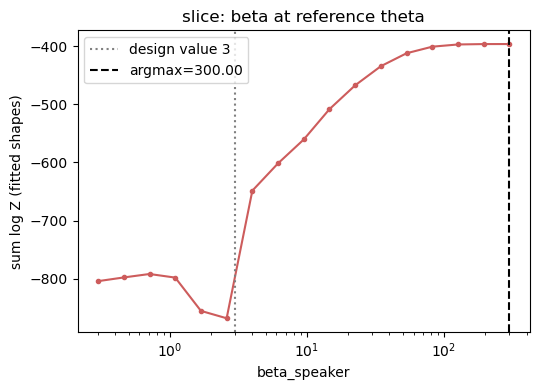

In [2]:
REF_LS, REF_MU, REF_SIGMA = 0.4, 0.0, 1.5
beta_grid = np.geomspace(0.3, 300.0, 17)
ll_beta_f = np.array([inf.total_log_lik_free_shapes(geom, responses_cond,
                                                    REF_LS, REF_MU, REF_SIGMA, beta_speaker=b)
                      for b in beta_grid])

plt.figure(figsize=(5.5, 4))
plt.plot(beta_grid, ll_beta_f, '-o', ms=3, color='indianred')
plt.axvline(inf.BETA_SPEAKER, color='gray', ls=':', label='design value 3')
plt.axvline(beta_grid[np.argmax(ll_beta_f)], color='k', ls='--',
            label=f'argmax={beta_grid[np.argmax(ll_beta_f)]:.2f}')
plt.xscale('log'); plt.xlabel('beta_speaker'); plt.ylabel('sum log Z (fitted shapes)')
plt.legend(); plt.title('slice: beta at reference theta'); plt.tight_layout(); plt.show()

## 2. 4-D VBMC, fitted (profiled) linking shapes

Cached to `results/study8-vbmc-laplace-beta/posterior-fitted-shapes.npz`.

In [3]:
# The default 4-D box (UB beta=30) truncates the study-8 posterior: the profile
# likelihood keeps rising past 30 and only saturates around beta ~100-300 (the
# epsilon-noisy speaker's ceiling). Widen the beta coordinate; prior unchanged.
inf.UB_4[3]  = np.log(1000.0)
inf.PUB_4[3] = np.log(300.0)

SAMPLE_KEYS = ('ls_samples', 'mu0_samples', 'sigma_samples', 'beta_samples')

def load_or_fit(path, fit_fn):
    if os.path.exists(path):
        z = np.load(path, allow_pickle=True)
        fit = {k: z[k] for k in SAMPLE_KEYS}
        fit.update(json.loads(str(z['meta'])))
        print(f"loaded cached posterior from {path}  ({fit['convergence_status']})")
    else:
        fit = fit_fn()
        np.savez_compressed(path, **{k: fit[k] for k in SAMPLE_KEYS},
                            meta=json.dumps({k: fit[k] for k in ('elbo', 'func_count',
                                                                 'convergence_status', 'runtime_s')}))
        print(f"saved posterior to {path}")
    return fit

fit_f = load_or_fit(os.path.join(RESULTS_DIR, 'posterior-fitted-shapes.npz'),
                    lambda: inf.run_vbmc_free_shapes_beta(geom, responses_cond, max_evals=MAX_EVALS))

Reshaping x0 to row vector.


Reshaping lower bounds to (1, 4).


Reshaping upper bounds to (1, 4).


Reshaping plausible lower bounds to (1, 4).


Reshaping plausible upper bounds to (1, 4).


...

    53        275        -263.44         0.13         0.00       25      0.173     stable


   inf        275        -263.35         0.15         0.01       50      0.173     finalize


Inference terminated: variational solution stable for options.tol_stable_count fcn evaluations.


Estimated ELBO: -263.348 +/-0.149.


saved posterior to results/study8-vbmc-laplace-beta/posterior-fitted-shapes.npz


## 3. Posterior marginals

convergence=probable  evals=275  ELBO=-263.3  runtime=78 min
length_scale    2.487 [1.639, 3.884]
mu_0           -0.015 [-0.213, 0.135]
sigma           2.232 [1.997, 2.490]
beta_speaker  279.772 [174.945, 561.981]


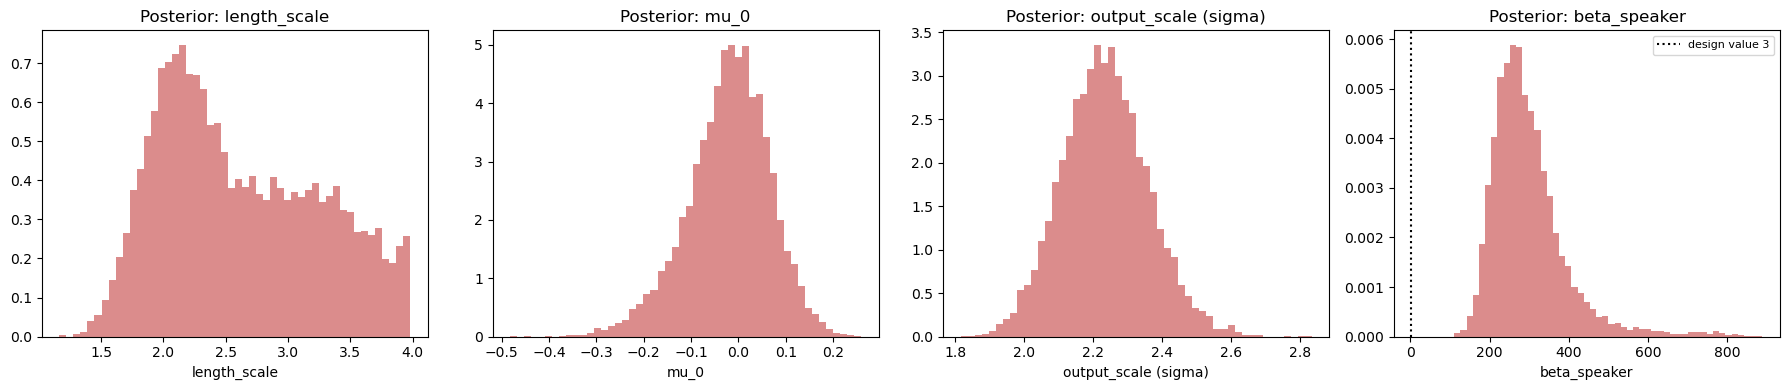

In [4]:
print(f"convergence={fit_f['convergence_status']}  evals={fit_f['func_count']}  "
      f"ELBO={fit_f['elbo']:.1f}  runtime={fit_f['runtime_s']/60:.0f} min")
def fmt(s): return f"{np.median(s):7.3f} [{np.percentile(s,2.5):.3f}, {np.percentile(s,97.5):.3f}]"
for name, key in [('length_scale', 'ls_samples'), ('mu_0', 'mu0_samples'),
                  ('sigma', 'sigma_samples'), ('beta_speaker', 'beta_samples')]:
    print(f"{name:<14}{fmt(fit_f[key])}")

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, key, name in zip(axes, ['ls_samples', 'mu0_samples', 'sigma_samples', 'beta_samples'],
                         ['length_scale', 'mu_0', 'output_scale (sigma)', 'beta_speaker']):
    ax.hist(fit_f[key], bins=50, density=True, color='indianred', alpha=0.7)
    if key == 'beta_samples':
        ax.axvline(inf.BETA_SPEAKER, color='k', ls=':', label='design value 3'); ax.legend(fontsize=8)
    ax.set_xlabel(name); ax.set_title(f'Posterior: {name}')
plt.tight_layout(); plt.show()

## 4. Forward pass at the posterior median

Per-group, per-feature predictions under the fitted per-feature linking shapes:
`pred_prior` = ratings-free coherence mode (pure prediction), `pred_posterior` =
ratings-conditioned mode (study 9 section-5 convention). Saved long-form to
`predictions.csv` with group metadata.

In [5]:
LS_B, MU_B, SIG_B, BETA_B = (float(np.median(fit_f['ls_samples'])), float(np.median(fit_f['mu0_samples'])),
                             float(np.median(fit_f['sigma_samples'])), float(np.median(fit_f['beta_samples'])))
print(f"Posterior median: ls={LS_B:.3f}, mu_0={MU_B:.3f}, sigma={SIG_B:.3f}, beta={BETA_B:.3f}")

_, shapes_f, cond_data_f = inf.total_log_lik_free_shapes(
    geom, responses_cond, LS_B, MU_B, SIG_B, beta_speaker=BETA_B, return_shapes=True)
mean_kl  = shapes_f[:, 0] / (shapes_f[:, 0] + shapes_f[:, 1])
mean_nkl = shapes_f[:, 2] / (shapes_f[:, 2] + shapes_f[:, 3])
np.savez_compressed(os.path.join(RESULTS_DIR, 'fitted-link-shapes.npz'),
                    shapes=shapes_f, feature_names=np.array(test_feature_names),
                    theta=np.array([LS_B, MU_B, SIG_B, BETA_B]))

pz1_prior = inf.prior_pz1_modes(geom, LS_B, MU_B, SIG_B, beta_speaker=BETA_B)
rows, n_bad = [], 0
for g in GROUPS:
    _, y_hat, ok = inf.laplace_log_Z(cond_data_f[g], LS_B, MU_B, SIG_B, beta_speaker=BETA_B)
    n_bad += (not ok)
    pz1_post = 1.0 / (1.0 + np.exp(-y_hat[:J]))
    pp  = pz1_post * mean_kl + (1 - pz1_post) * mean_nkl
    ppr = np.asarray(pz1_prior[g]) * mean_kl + (1 - np.asarray(pz1_prior[g])) * mean_nkl
    emp_g = np.array(responses_cond[g]).mean(0)
    m = meta.loc[g]
    for j, f in enumerate(test_feature_names):
        rows.append({'group': g, 'condition': m['condition'],
                     'num_generics': int(m['num_generics']), 'total_utt': int(m['total_utt']),
                     'n_participants': int(m['n_participants']), 'feature': f,
                     'empirical_mean': float(emp_g[j]), 'pz1_prior': float(pz1_prior[g][j]),
                     'pred_prior': float(ppr[j]), 'pred_posterior': float(pp[j])})
if n_bad:
    print(f"warning: {n_bad} groups' Laplace modes not cleanly converged")
pred_df = pd.DataFrame(rows)
pred_df.to_csv(os.path.join(RESULTS_DIR, 'predictions.csv'), index=False)
print(f"saved {len(pred_df)} rows to {RESULTS_DIR}/predictions.csv")

Posterior median: ls=2.487, mu_0=-0.015, sigma=2.232, beta=279.772


saved 6448 rows to results/study8-vbmc-laplace-beta/predictions.csv


## 5. Predicted vs empirical per condition

Group predictions aggregated to condition × feature (participant-weighted), one panel per
design condition, ratings-free predictions on the y-axis.

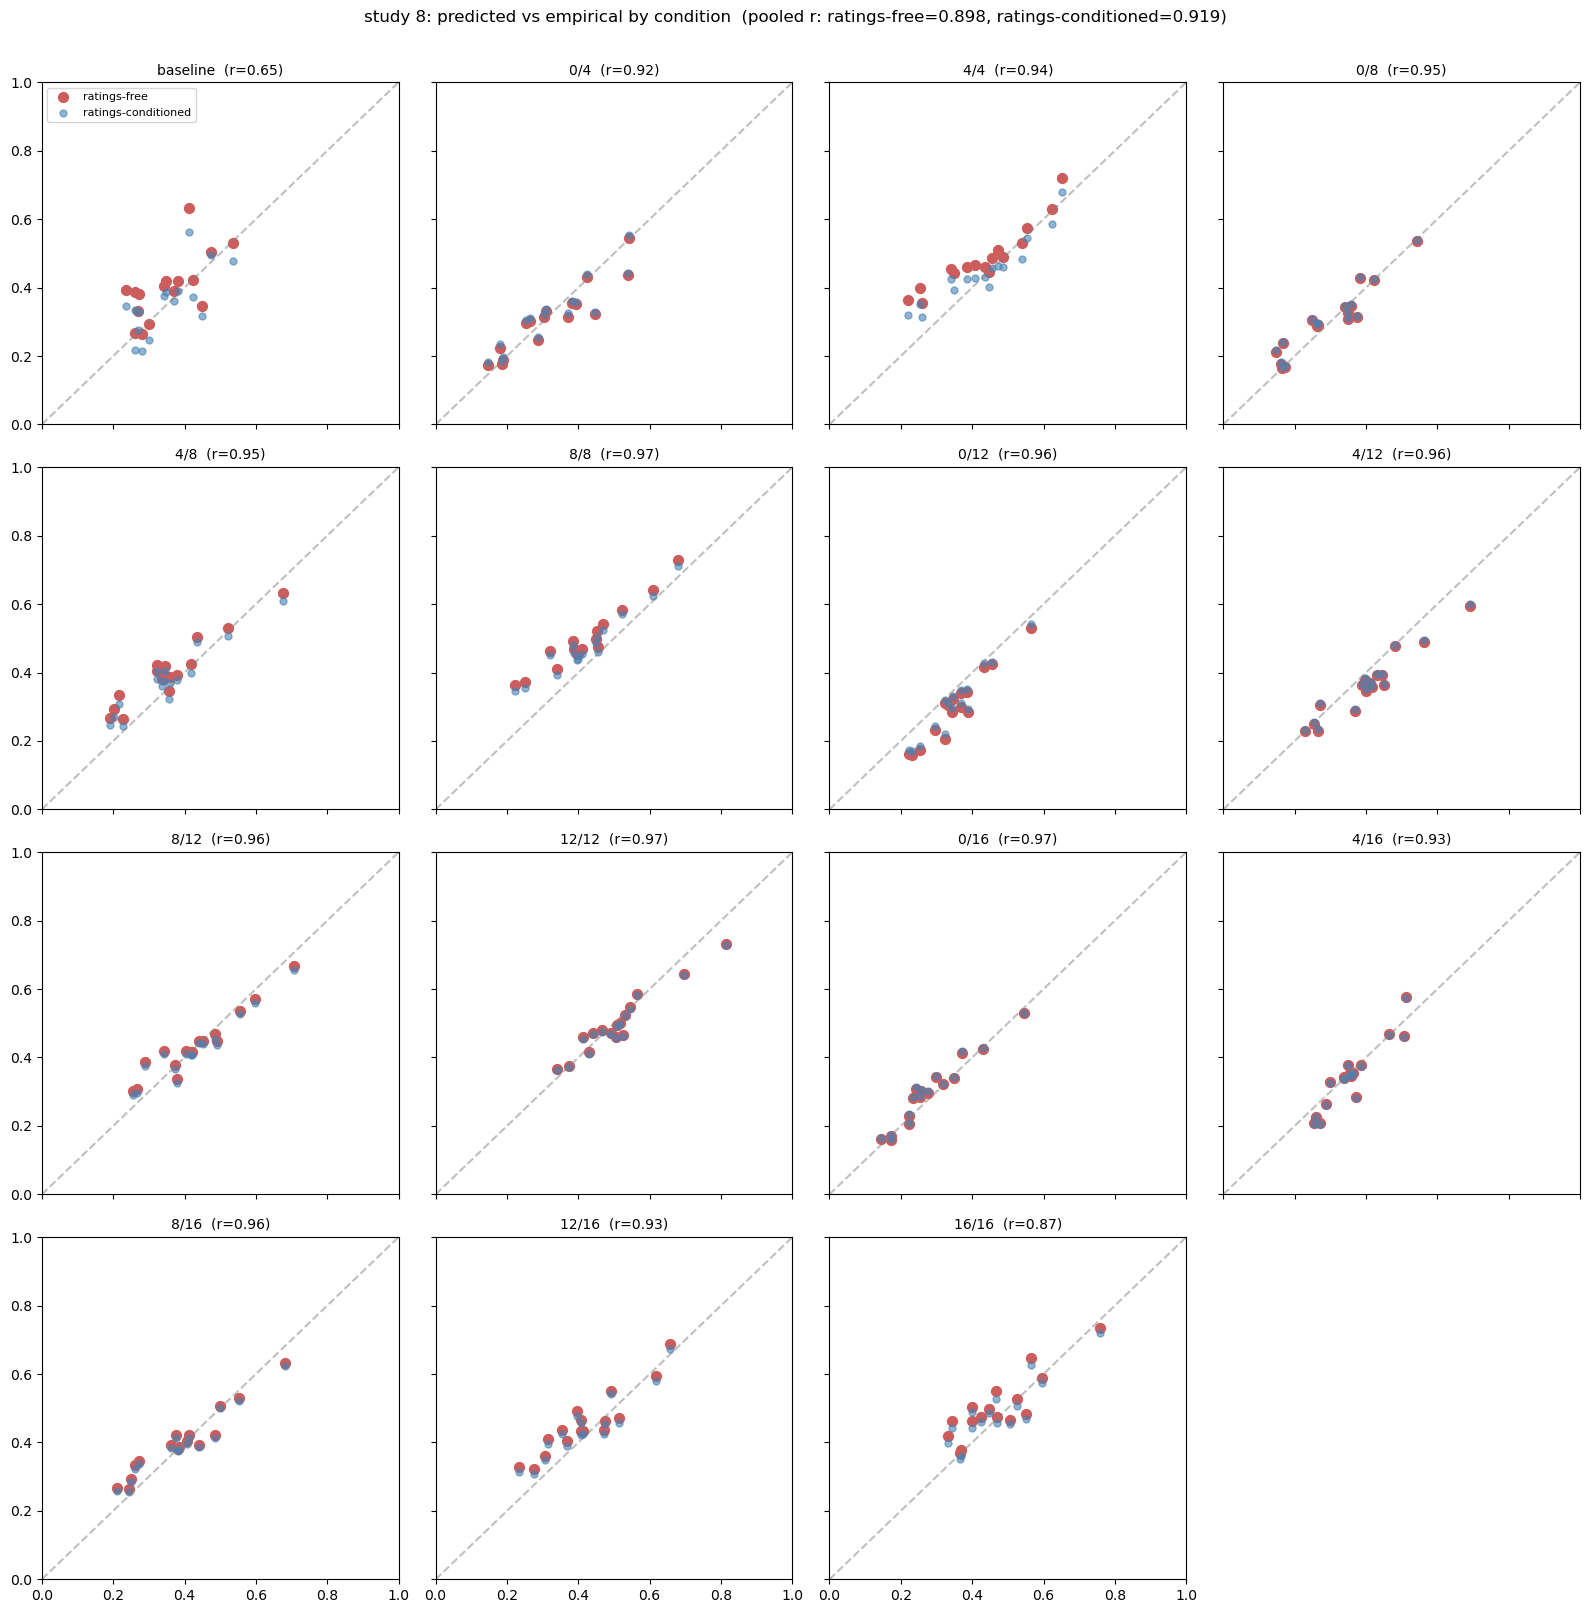

In [6]:
def wavg(d, col): return float(np.average(d[col], weights=d['n_participants']))
cf = (pred_df.groupby(['condition', 'feature'])
      .apply(lambda d: pd.Series({'empirical': wavg(d, 'empirical_mean'),
                                  'pred_prior': wavg(d, 'pred_prior'),
                                  'pred_post': wavg(d, 'pred_posterior')}),
             include_groups=False)
      .reset_index())

cond_meta = groups_df.groupby('condition')[['num_generics', 'total_utt']].first()
cond_order = sorted(cf['condition'].unique(),
                    key=lambda c: (cond_meta.loc[c, 'total_utt'], cond_meta.loc[c, 'num_generics']))

fig, axes = plt.subplots(4, 4, figsize=(16, 16), sharex=True, sharey=True)
for ax, c in zip(axes.ravel(), cond_order):
    d = cf[cf.condition == c]
    ax.scatter(d['empirical'], d['pred_prior'], s=50, color='indianred', label='ratings-free')
    ax.scatter(d['empirical'], d['pred_post'], s=25, color='steelblue', alpha=0.6,
               label='ratings-conditioned')
    ax.plot([0, 1], [0, 1], '--', color='gray', alpha=0.5)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    r = np.corrcoef(d['empirical'], d['pred_prior'])[0, 1]
    ax.set_title(f"{c}  (r={r:.2f})", fontsize=10)
for ax in axes.ravel()[len(cond_order):]:
    ax.axis('off')
axes[0, 0].legend(fontsize=8)
r_prior = np.corrcoef(cf['empirical'], cf['pred_prior'])[0, 1]
r_post  = np.corrcoef(cf['empirical'], cf['pred_post'])[0, 1]
fig.suptitle(f'study 8: predicted vs empirical by condition  '
             f'(pooled r: ratings-free={r_prior:.3f}, ratings-conditioned={r_post:.3f})', y=1.005)
plt.tight_layout(); plt.show()

## 6. Condition means vs proportion of generics

The design's key manipulation: rated prevalence of the test features should rise with the
proportion of generics heard. Human means vs model (ratings-free) predictions, one line per
`total_utt`; baseline as the leftmost point.

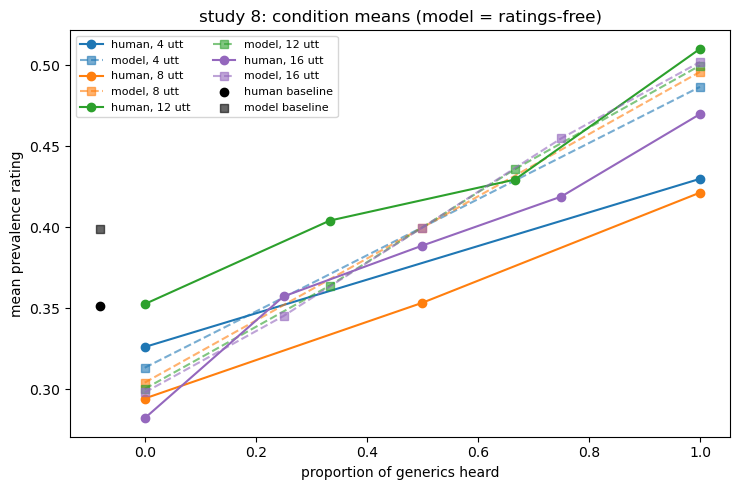

In [7]:
csum = (pred_df.groupby('condition')
        .apply(lambda d: pd.Series({'empirical': wavg(d, 'empirical_mean'),
                                    'pred_prior': wavg(d, 'pred_prior'),
                                    'num_generics': d['num_generics'].iloc[0],
                                    'total_utt': d['total_utt'].iloc[0]}),
               include_groups=False)
        .reset_index())

tcol = {4: 'tab:blue', 8: 'tab:orange', 12: 'tab:green', 16: 'tab:purple'}
plt.figure(figsize=(7.5, 5))
for t, col in tcol.items():
    d = csum[(csum.total_utt == t) & (csum.condition != 'baseline')].sort_values('num_generics')
    p = d['num_generics'] / d['total_utt']
    plt.plot(p, d['empirical'], '-o', color=col, label=f'human, {t} utt')
    plt.plot(p, d['pred_prior'], '--s', color=col, alpha=0.6, label=f'model, {t} utt')
b = csum[csum.condition == 'baseline']
plt.scatter([-0.08], b['empirical'], color='k', zorder=3, label='human baseline')
plt.scatter([-0.08], b['pred_prior'], color='k', marker='s', alpha=0.6, zorder=3,
            label='model baseline')
plt.xlabel('proportion of generics heard'); plt.ylabel('mean prevalence rating')
plt.legend(fontsize=8, ncol=2); plt.title('study 8: condition means (model = ratings-free)')
plt.tight_layout(); plt.show()